# 🔥 ROCm (Radeon 890M) Quick Start

This notebook verifies your PyTorch + AMD ROCm (Radeon 890M) setup and runs basic GPU-accelerated operations on AMD Ryzen AI HX 370.

In [1]:
import torch
from metalcheck import device_info, get_device, is_rocm_available
from metalcheck.utils import benchmark_matmul

## 1. Device & System Information

In [2]:
info = device_info()
for k, v in info.items():
    label = k.replace("_", " ").title()
    print(f"{label:<20s}: {v}")

Pytorch Version     : 2.8.0+rocm7.1.0.git7a520360
Python Version      : 3.12.3
Platform            : Linux-6.19.8-arch1-1-x86_64-with-glibc2.39
Architecture        : x86_64
Mps Built           : False
Mps Available       : False
Cuda Available      : True
Rocm Available      : True
Device              : cuda
Hip Version         : 7.1.25424-4179531dcd
Cuda Device Name    : AMD Radeon Graphics


## 2. Basic Tensor Operations on ROCm

In [3]:
device = get_device()
print(f"Using device: {device}")

a = torch.randn(4, 4, device=device)
b = torch.randn(4, 4, device=device)
c = a @ b

print("Matrix A:")
print(a)
print("Matrix B:")
print(b)
print("A @ B:")
print(c)

Using device: cuda
Matrix A:
tensor([[ 0.3453,  0.7378,  0.6922,  0.1285],
        [-0.8786, -0.8217, -1.2346, -1.8219],
        [-0.2292, -0.8099, -0.2083,  0.4285],
        [ 0.2264,  0.1394,  2.2702, -1.7816]], device='cuda:0')
Matrix B:
tensor([[-1.4370,  0.7941,  0.4265,  0.9079],
        [ 0.6003,  0.2304,  0.6662, -1.0759],
        [ 0.1277,  0.9268, -0.3423,  0.0326],
        [ 1.9702,  0.6873,  0.6794, -1.0411]], device='cuda:0')
A @ B:
tensor([[ 0.2882,  1.1740,  0.4892, -0.5915],
        [-2.9778, -3.2834, -1.7373,  1.9430],
        [ 0.6608, -0.2671, -0.2748,  0.2103],
        [-3.4619,  1.0913, -1.7981,  1.9845]], device='cuda:0')


## 3. ROCm vs CPU Benchmark

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sizes = [256, 512, 1024, 2048, 4096] #, 8192]
rocm_times = []
cpu_times = []

for size in sizes:
    if is_rocm_available():
        r = benchmark_matmul(size=size, device=torch.device("cuda"), iterations=10)
        rocm_times.append(r["mean_time_s"] * 1000)
    r = benchmark_matmul(size=size, device=torch.device("cpu"), iterations=10)
    cpu_times.append(r["mean_time_s"] * 1000)

print("Benchmark complete!")

Benchmark complete!


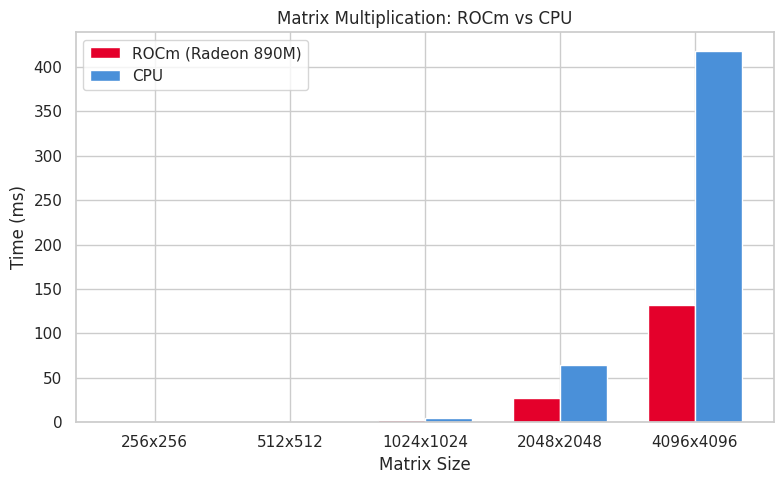

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

x = range(len(sizes))
width = 0.35

if rocm_times:
    ax.bar([i - width / 2 for i in x], rocm_times, width, label="ROCm (Radeon 890M)", color="#E4002B")
ax.bar([i + width / 2 for i in x], cpu_times, width, label="CPU", color="#4A90D9")

ax.set_xlabel("Matrix Size")
ax.set_ylabel("Time (ms)")
ax.set_title("Matrix Multiplication: ROCm vs CPU")
ax.set_xticks(list(x))
ax.set_xticklabels([f"{s}x{s}" for s in sizes])
ax.legend()

plt.tight_layout()
plt.show()

## 4. Speedup Summary

In [6]:
if rocm_times and cpu_times:
    import pandas as pd
    df = pd.DataFrame({
        "Size": [f"{s}x{s}" for s in sizes],
        "ROCm (ms)": [f"{t:.2f}" for t in rocm_times],
        "CPU (ms)": [f"{t:.2f}" for t in cpu_times],
        "Speedup": [f"{c / m:.1f}x" for c, m in zip(cpu_times, rocm_times)],
    })
    display(df)
else:
    print("ROCm not available — ran CPU only.")

,Size,ROCm (ms),CPU (ms),Speedup
0,256x256,0.19,0.14,0.7x
1,512x512,0.62,0.53,0.8x
2,1024x1024,2.08,5.33,2.6x
3,2048x2048,26.98,64.32,2.4x
4,4096x4096,131.46,418.05,3.2x
